In [1]:
from __future__ import annotations

"""
Veronesi book-accurate benchmark for the mortgage / RMBS pipeline.

This script is designed to mirror the logic in Pietro Veronesi,
*Fixed Income Securities: Valuation, Risk, and Risk Management*,
Part II / Chapters 11, 12, and 13.

It is intentionally split into the same stages used in the book:

1) Chapter 11:
   - calibrate a Ho-Lee risk-neutral tree
   - calibrate a simple BDT risk-neutral tree
2) Chapter 12:
   - compute the mortgage without prepayment
   - compute the American prepayment option
   - extract trigger rates
   - price pass-through / IO / PO strips on the tree
3) Chapter 13.6:
   - simulate mortgage cash flows on the simple BDT tree using trigger rates
   - compute Monte Carlo price, standard error, and confidence interval

The built-in benchmark run uses the simple BDT mortgage example from Chapters 12-13:
- semiannual grid out to 5 years
- zero prices from Table 12.7
- simple BDT volatility sigma = 21.42%
- mortgage principal = 100,000
- pass-through coupon = 7%

The goal is not to be fancy. The goal is to be logically faithful.
"""

from dataclasses import dataclass
from math import exp, log, sqrt, isclose
from typing import Iterable, List, Sequence, Tuple
import random

try:
    from statistics import mean, stdev
except ImportError:  # pragma: no cover
    mean = None
    stdev = None

try:
    from scipy.optimize import brentq
except Exception as exc:  # pragma: no cover
    raise RuntimeError(
        "This script requires scipy.optimize.brentq for the one-dimensional root solves."
    ) from exc


# -----------------------------------------------------------------------------
# Data containers
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class ZeroCurve:
    maturities: Tuple[float, ...]
    zero_prices: Tuple[float, ...]

    @property
    def dt(self) -> float:
        if len(self.maturities) < 2:
            return self.maturities[0]
        steps = [self.maturities[i] - self.maturities[i - 1] for i in range(1, len(self.maturities))]
        first = self.maturities[0]
        all_steps = [first] + steps
        ref = all_steps[0]
        for x in all_steps:
            if abs(x - ref) > 1e-10:
                raise ValueError("Maturities must sit on a regular grid.")
        return ref


@dataclass(frozen=True)
class MortgageSchedule:
    coupon_per_period: float
    interest_paid: Tuple[float, ...]
    principal_paid: Tuple[float, ...]
    outstanding_principal: Tuple[float, ...]


@dataclass(frozen=True)
class TreePricingResult:
    mortgage_rate: float
    coupon_per_period: float
    no_prepay_tree: Tuple[Tuple[float, ...], ...]
    option_tree: Tuple[Tuple[float, ...], ...]
    mortgage_tree: Tuple[Tuple[float, ...], ...]
    trigger_rates: Tuple[float | None, ...]
    schedule: MortgageSchedule


@dataclass(frozen=True)
class MonteCarloSummary:
    mean_value: float
    standard_error: float
    ci_low: float
    ci_high: float


# -----------------------------------------------------------------------------
# Generic tree helpers
# -----------------------------------------------------------------------------


def check_recombining_tree(tree: Sequence[Sequence[float]]) -> None:
    for i, row in enumerate(tree):
        if len(row) != i + 1:
            raise ValueError(f"Level {i} must contain {i+1} nodes, got {len(row)}.")



def tree_zero_price(tree: Sequence[Sequence[float]], maturity_step: int, dt: float) -> float:
    """
    Price a zero-coupon bond maturing at step `maturity_step` on a risk-neutral tree.

    Convention follows the book:
    - risk-neutral probability is p* = 1/2
    - an upward movement keeps j constant
    - a downward movement increments j by 1
    - rates are continuously compounded short rates for each interval of length dt
    """
    check_recombining_tree(tree)
    if maturity_step < 1:
        return 1.0
    values = [1.0] * (maturity_step + 1)
    for i in range(maturity_step - 1, -1, -1):
        next_values = []
        for j in range(i + 1):
            v = exp(-tree[i][j] * dt) * 0.5 * (values[j] + values[j + 1])
            next_values.append(v)
        values = next_values
    return values[0]



def reprice_zero_curve(tree: Sequence[Sequence[float]], dt: float) -> List[float]:
    return [tree_zero_price(tree, m, dt) for m in range(1, len(tree) + 1)]


# -----------------------------------------------------------------------------
# Chapter 11: risk-neutral tree calibration
# -----------------------------------------------------------------------------


def calibrate_simple_bdt_from_zero_prices(
    zero_prices: Sequence[float],
    dt: float,
    sigma: float,
) -> List[List[float]]:
    """
    Calibrate the simple BDT tree exactly to the zero curve.

    Model:
        z_{i+1,j}   = z_{i,j} + theta_i * dt + sigma * sqrt(dt)
        z_{i+1,j+1} = z_{i,j} + theta_i * dt - sigma * sqrt(dt)
        r_{i,j} = exp(z_{i,j})

    Equivalent implementation used here:
        each level i is identified by its top log-rate alpha_i,
        z_{i,j} = alpha_i - 2*j*sigma*sqrt(dt).
    """
    n = len(zero_prices)
    if n < 1:
        raise ValueError("Need at least one zero price.")
    if not (0.0 < zero_prices[0] < 1.0):
        raise ValueError("First zero price must be in (0,1).")

    s = sigma * sqrt(dt)
    tree: List[List[float]] = [[-log(zero_prices[0]) / dt]]
    alphas = [log(tree[0][0])]

    for level in range(1, n):
        target = zero_prices[level]

        def objective(alpha_top: float) -> float:
            row = [exp(alpha_top - 2.0 * j * s) for j in range(level + 1)]
            candidate = tree + [row]
            return tree_zero_price(candidate, level + 1, dt) - target

        lo, hi = -12.0, 4.0
        flo, fhi = objective(lo), objective(hi)
        while flo * fhi > 0:
            lo -= 4.0
            hi += 2.0
            flo, fhi = objective(lo), objective(hi)
            if lo < -200 or hi > 50:
                raise RuntimeError("Failed to bracket simple BDT calibration root.")

        alpha_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
        alphas.append(alpha_star)
        tree.append([exp(alpha_star - 2.0 * j * s) for j in range(level + 1)])

    return tree



def calibrate_ho_lee_from_zero_prices(
    zero_prices: Sequence[float],
    dt: float,
    sigma: float,
) -> List[List[float]]:
    """
    Calibrate the Ho-Lee risk-neutral tree exactly to the zero curve.

    Model:
        r_{i+1,j}   = r_{i,j} + theta_i * dt + sigma * sqrt(dt)
        r_{i+1,j+1} = r_{i,j} + theta_i * dt - sigma * sqrt(dt)

    Equivalent implementation used here:
        each level i is identified by its top rate top_i,
        r_{i,j} = top_i - 2*j*sigma*sqrt(dt).
    """
    n = len(zero_prices)
    if n < 1:
        raise ValueError("Need at least one zero price.")
    first_rate = -log(zero_prices[0]) / dt
    tree: List[List[float]] = [[first_rate]]
    jump = 2.0 * sigma * sqrt(dt)

    for level in range(1, n):
        target = zero_prices[level]

        def objective(top_rate: float) -> float:
            row = [top_rate - j * jump for j in range(level + 1)]
            candidate = tree + [row]
            return tree_zero_price(candidate, level + 1, dt) - target

        # For realistic data there is usually a valid bracket around ordinary rate levels.
        lo, hi = -0.50, 0.80
        flo, fhi = objective(lo), objective(hi)
        while flo * fhi > 0:
            lo -= 0.50
            hi += 0.50
            flo, fhi = objective(lo), objective(hi)
            if lo < -10 or hi > 10:
                raise RuntimeError("Failed to bracket Ho-Lee calibration root.")

        top_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
        tree.append([top_star - j * jump for j in range(level + 1)])

    return tree


# -----------------------------------------------------------------------------
# Chapter 11 empirical sigma utilities
# -----------------------------------------------------------------------------


def estimate_sigma_ho_lee(rate_series: Sequence[float], obs_per_year: float) -> float:
    """Annualized sigma for Ho-Lee = stdev of level changes times sqrt(obs_per_year)."""
    if len(rate_series) < 2:
        raise ValueError("Need at least two observations.")
    diffs = [rate_series[i] - rate_series[i - 1] for i in range(1, len(rate_series))]
    if len(diffs) < 2:
        raise ValueError("Need at least two differences to compute a sample standard deviation.")
    return stdev(diffs) * sqrt(obs_per_year)



def estimate_sigma_simple_bdt(rate_series: Sequence[float], obs_per_year: float) -> float:
    """Annualized sigma for simple BDT = stdev of log-rate changes times sqrt(obs_per_year)."""
    if len(rate_series) < 2:
        raise ValueError("Need at least two observations.")
    if any(r <= 0 for r in rate_series):
        raise ValueError("Simple BDT volatility requires strictly positive rates.")
    diffs = [log(rate_series[i]) - log(rate_series[i - 1]) for i in range(1, len(rate_series))]
    if len(diffs) < 2:
        raise ValueError("Need at least two differences to compute a sample standard deviation.")
    return stdev(diffs) * sqrt(obs_per_year)


# -----------------------------------------------------------------------------
# Chapter 8/12: mortgage schedule and valuation
# -----------------------------------------------------------------------------


def mortgage_schedule(principal: float, annual_rate: float, n_periods: int, dt: float) -> MortgageSchedule:
    """
    Fixed-rate fully amortizing mortgage schedule.

    Continuous compounding is used in the tree discounting, but mortgage coupon cash flows
    in the book example are ordinary discrete semiannual payments.
    """
    if not (principal > 0):
        raise ValueError("Principal must be positive.")
    if not (n_periods >= 1):
        raise ValueError("Need at least one period.")
    if not (dt > 0):
        raise ValueError("dt must be positive.")

    period_rate = annual_rate * dt
    if abs(period_rate) < 1e-16:
        coupon = principal / n_periods
    else:
        coupon = principal * period_rate / (1.0 - (1.0 + period_rate) ** (-n_periods))

    outstanding = [principal]
    interest_paid = [0.0]
    principal_paid = [0.0]

    bal = principal
    for k in range(1, n_periods + 1):
        interest = bal * period_rate
        principal_component = coupon - interest
        # clean up final period rounding drift
        if k == n_periods:
            principal_component = bal
            coupon_k = interest + principal_component
        else:
            coupon_k = coupon
        bal = bal - principal_component
        if abs(bal) < 1e-10:
            bal = 0.0
        interest_paid.append(interest)
        principal_paid.append(principal_component)
        outstanding.append(bal)
        coupon = coupon_k  # only changes in the final period if rounding was corrected

    # Keep the book convention: coupon amount is constant except for tiny numerical cleanup.
    coupon_per_period = interest_paid[1] + principal_paid[1]
    return MortgageSchedule(
        coupon_per_period=coupon_per_period,
        interest_paid=tuple(interest_paid),
        principal_paid=tuple(principal_paid),
        outstanding_principal=tuple(outstanding),
    )



def price_no_prepay_mortgage(
    tree: Sequence[Sequence[float]],
    coupon_per_period: float,
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 recursion for the mortgage without the prepayment option:
        V^np_{i,j} = exp(-r_{i,j} dt) * (0.5 V^np_{i+1,j} + 0.5 V^np_{i+1,j+1} + C)
    with terminal value 0 at maturity.
    """
    check_recombining_tree(tree)
    n = len(tree)
    values: List[List[float]] = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        for j in range(i + 1):
            cont = 0.5 * values[i + 1][j] + 0.5 * values[i + 1][j + 1] + coupon_per_period
            values[i][j] = exp(-tree[i][j] * dt) * cont
    return values



def price_prepayment_option(
    tree: Sequence[Sequence[float]],
    no_prepay_tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 American refinancing option logic.

    Exercise payoff:
        C^Exercise_{i,j} = max(V^np_{i,j} - L_i, 0)
    Wait value:
        C^Wait_{i,j} = exp(-r_{i,j} dt) * 0.5 * (C_{i+1,j} + C_{i+1,j+1})
    Option value:
        C_{i,j} = max(C^Wait_{i,j}, C^Exercise_{i,j})

    Important: to match the book literally, trigger extraction later uses the strict rule
    "exercise when exercise value > wait value".
    """
    check_recombining_tree(tree)
    n = len(tree)
    option: List[List[float]] = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        for j in range(i + 1):
            wait = exp(-tree[i][j] * dt) * 0.5 * (option[i + 1][j] + option[i + 1][j + 1])
            if i == 0:
                # Book benchmark: no immediate refinancing at initiation.
                option[i][j] = wait
            else:
                exercise = max(no_prepay_tree[i][j] - Li, 0.0)
                option[i][j] = max(wait, exercise)
    return option



def extract_trigger_rates(
    tree: Sequence[Sequence[float]],
    no_prepay_tree: Sequence[Sequence[float]],
    option_tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    dt: float,
) -> List[float | None]:
    """
    Extract the trigger rate in each period i using the book's strict exercise test:
    refinance whenever C^Exercise_{i,j} > C^Wait_{i,j}.

    The trigger is reported as the highest rate at which strict exercise is optimal in period i.
    If no node exercises, trigger is None.
    """
    n = len(tree)
    triggers: List[float | None] = [None] * (n + 1)
    triggers[0] = None
    for i in range(1, n):
        Li = outstanding_principal[i]
        exercising_rates: List[float] = []
        for j in range(i + 1):
            exercise = max(no_prepay_tree[i][j] - Li, 0.0)
            wait = exp(-tree[i][j] * dt) * 0.5 * (option_tree[i + 1][j] + option_tree[i + 1][j + 1])
            if exercise > wait:
                exercising_rates.append(tree[i][j])
        triggers[i] = max(exercising_rates) if exercising_rates else None
    triggers[n] = None
    return triggers



def mortgage_tree_from_components(
    no_prepay_tree: Sequence[Sequence[float]],
    option_tree: Sequence[Sequence[float]],
) -> List[List[float]]:
    return [
        [no_prepay_tree[i][j] - option_tree[i][j] for j in range(i + 1)]
        for i in range(len(no_prepay_tree))
    ]



def solve_par_mortgage_rate(
    tree: Sequence[Sequence[float]],
    principal: float,
    dt: float,
) -> TreePricingResult:
    """
    Solve for the mortgage rate such that mortgage value at inception equals principal.
    """
    n_periods = len(tree)

    def objective(annual_rate: float) -> float:
        sched = mortgage_schedule(principal=principal, annual_rate=annual_rate, n_periods=n_periods, dt=dt)
        vnp = price_no_prepay_mortgage(tree, sched.coupon_per_period, dt)
        opt = price_prepayment_option(tree, vnp, sched.outstanding_principal, dt)
        mort0 = vnp[0][0] - opt[0][0]
        return mort0 - principal

    lo, hi = 1e-6, 0.50
    flo, fhi = objective(lo), objective(hi)
    while flo * fhi > 0:
        hi *= 1.5
        fhi = objective(hi)
        if hi > 5.0:
            raise RuntimeError("Failed to bracket mortgage-rate root.")

    rate_star = brentq(objective, lo, hi, xtol=1e-14, rtol=1e-12, maxiter=500)
    sched = mortgage_schedule(principal=principal, annual_rate=rate_star, n_periods=n_periods, dt=dt)
    vnp = price_no_prepay_mortgage(tree, sched.coupon_per_period, dt)
    opt = price_prepayment_option(tree, vnp, sched.outstanding_principal, dt)
    mort = mortgage_tree_from_components(vnp, opt)
    triggers = extract_trigger_rates(tree, vnp, opt, sched.outstanding_principal, dt)
    return TreePricingResult(
        mortgage_rate=rate_star,
        coupon_per_period=sched.coupon_per_period,
        no_prepay_tree=tuple(tuple(row) for row in vnp),
        option_tree=tuple(tuple(row) for row in opt),
        mortgage_tree=tuple(tuple(row) for row in mort),
        trigger_rates=tuple(triggers),
        schedule=sched,
    )


# -----------------------------------------------------------------------------
# Chapter 12: pass-through / IO / PO pricing on the tree
# -----------------------------------------------------------------------------


def price_pass_through_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    scheduled_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    pass_through_rate: float,
    dt: float,
) -> List[List[float]]:
    """
    Chapter 12 pass-through recursion.

    If prepayment occurs at node (i,j):
        PPT_{i,j} = L_i
    Otherwise:
        PPT_{i,j} = exp(-r_{i,j} dt) * (0.5 next_up + 0.5 next_down + CF(i+1))
    where CF(i+1) = pass-through interest on L_i plus scheduled principal at i+1.
    """
    n = len(tree)
    pt = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        cf_next = Li * pass_through_rate * dt + scheduled_principal[i + 1]
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                pt[i][j] = outstanding_principal[i]
            else:
                pt[i][j] = exp(-r * dt) * (0.5 * pt[i + 1][j] + 0.5 * pt[i + 1][j + 1] + cf_next)
    return pt



def price_po_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    scheduled_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    dt: float,
) -> List[List[float]]:
    n = len(tree)
    po = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        principal_cf_next = scheduled_principal[i + 1]
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                po[i][j] = outstanding_principal[i]
            else:
                po[i][j] = exp(-r * dt) * (0.5 * po[i + 1][j] + 0.5 * po[i + 1][j + 1] + principal_cf_next)
    return po



def price_io_on_tree(
    tree: Sequence[Sequence[float]],
    outstanding_principal: Sequence[float],
    trigger_rates: Sequence[float | None],
    pass_through_rate: float,
    dt: float,
) -> List[List[float]]:
    n = len(tree)
    io = [[0.0] * (i + 1) for i in range(n + 1)]
    for i in range(n - 1, -1, -1):
        Li = outstanding_principal[i]
        interest_cf_next = Li * pass_through_rate * dt
        trig = trigger_rates[i]
        for j in range(i + 1):
            r = tree[i][j]
            if trig is not None and r <= trig:
                io[i][j] = 0.0
            else:
                io[i][j] = exp(-r * dt) * (0.5 * io[i + 1][j] + 0.5 * io[i + 1][j + 1] + interest_cf_next)
    return io


# -----------------------------------------------------------------------------
# Chapter 13.6.1: Monte Carlo mortgage valuation on the tree using trigger rates
# -----------------------------------------------------------------------------


def simulate_tree_path_indices(n_intervals: int, rng: random.Random) -> List[int]:
    """Return j-indices for tree levels 0..n_intervals-1 along one risk-neutral path."""
    j = 0
    path = [0]
    for _ in range(1, n_intervals):
        u = rng.random()
        if u >= 0.5:
            j += 1  # downward movement in the book's indexing
        path.append(j)
    return path



def discount_factor_along_path(tree: Sequence[Sequence[float]], path_j: Sequence[int], k: int, dt: float) -> float:
    """Discount from time 0 to payment date T_k using rates on intervals 0..k-1."""
    accum = 0.0
    for m in range(k):
        accum += tree[m][path_j[m]]
    return exp(-accum * dt)



def price_mortgage_mc_trigger_rule(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    trigger_rates: Sequence[float | None],
    dt: float,
    n_sims: int = 100000,
    seed: int = 12345,
) -> MonteCarloSummary:
    """
    Chapter 13.6.1 benchmark mortgage Monte Carlo.

    Logic:
    - simulate short-rate paths on the simple BDT tree with p*=1/2
    - at payment date k, inspect the short rate for period k (tree level k)
    - if it falls below the trigger for that period, prepay the whole remaining principal
      at that payment date together with the scheduled interest for that date
    - before trigger is hit, only scheduled coupon cash flows are paid
    - average discounted path values over simulations
    """
    rng = random.Random(seed)
    n = len(tree)  # number of payment dates
    path_values: List[float] = []

    for _ in range(n_sims):
        path_j = simulate_tree_path_indices(n, rng)
        pv = 0.0
        prepaid = False

        for k in range(1, n + 1):
            df = discount_factor_along_path(tree, path_j, k, dt)
            scheduled_interest = schedule.interest_paid[k]
            scheduled_principal = schedule.principal_paid[k]

            if k < n:
                rate_at_payment_date = tree[k][path_j[k]]
                trig = trigger_rates[k]
            else:
                rate_at_payment_date = None
                trig = None

            if (not prepaid) and (k < n) and (trig is not None) and (rate_at_payment_date is not None) and (rate_at_payment_date <= trig):
                # Book-consistent prepayment cash flow: scheduled interest at k + full outstanding
                # principal before the k-th scheduled principal payment.
                cashflow = scheduled_interest + schedule.outstanding_principal[k - 1]
                pv += df * cashflow
                prepaid = True
                break
            else:
                cashflow = scheduled_interest + scheduled_principal
                pv += df * cashflow

        path_values.append(pv)

    mu = mean(path_values)
    se = stdev(path_values) / sqrt(n_sims)
    return MonteCarloSummary(mu, se, mu - 2.0 * se, mu + 2.0 * se)


# -----------------------------------------------------------------------------
# Reporting helpers
# -----------------------------------------------------------------------------


def fmt_pct(x: float | None, digits: int = 2) -> str:
    if x is None:
        return "-"
    return f"{100.0 * x:.{digits}f}%"



def fmt_money(x: float, digits: int = 0) -> str:
    return f"${x:,.{digits}f}"



def print_tree_slice(name: str, tree: Sequence[Sequence[float]], levels: int = 5, pct: bool = True) -> None:
    print(f"\n{name} (first {levels} levels)")
    for i, row in enumerate(tree[:levels]):
        formatted = []
        for x in row:
            formatted.append(f"{100*x:8.4f}%" if pct else f"{x:12.6f}")
        print(f"level {i:>2}: " + " ".join(formatted))

In [2]:

# -----------------------------------------------------------------------------
# Built-in book benchmark dataset
# -----------------------------------------------------------------------------


def get_book_zero_curve_table_12_7() -> ZeroCurve:
    maturities = tuple(0.5 * i for i in range(1, 11))
    zero_prices = tuple(x / 100.0 for x in [97.11, 94.00, 90.86, 87.77, 84.79, 81.94, 79.26, 76.59, 74.14, 71.70])
    return ZeroCurve(maturities=maturities, zero_prices=zero_prices)


# -----------------------------------------------------------------------------
# Main benchmark runner
# -----------------------------------------------------------------------------

curve = get_book_zero_curve_table_12_7()
dt = curve.dt
sigma_bdt = 0.2142  # 21.42% from the simple BDT example
sigma_hl = 0.0311   # a reasonable HL benchmark level; not needed for mortgage run

print("Veronesi benchmark: Chapter 11 -> Chapter 12 -> Chapter 13.6")
print("=" * 72)
print("Zero curve (Table 12.7 / mortgage example):")
for T, Z in zip(curve.maturities, curve.zero_prices):
    y = -log(Z) / T
    print(f"  T={T:>3.1f}  Z(0,T)={Z:0.4f}  y={100*y:0.4f}%")

# Chapter 11 trees
hl_tree = calibrate_ho_lee_from_zero_prices(curve.zero_prices, dt, sigma_hl)
bdt_tree = calibrate_simple_bdt_from_zero_prices(curve.zero_prices, dt, sigma_bdt)

print_tree_slice("Ho-Lee tree", hl_tree, levels=5)
print_tree_slice("Simple BDT tree", bdt_tree, levels=5)

bdt_repriced = reprice_zero_curve(bdt_tree, dt)
max_curve_error = max(abs(a - b) for a, b in zip(bdt_repriced, curve.zero_prices))
print(f"\nSimple BDT repricing max abs error: {max_curve_error:.3e}")

# Chapter 12 mortgage
principal = 100000.0
pt_coupon = 0.07
mortgage = solve_par_mortgage_rate(bdt_tree, principal=principal, dt=dt)
no_prepay_0 = mortgage.no_prepay_tree[0][0]
option_0 = mortgage.option_tree[0][0]
mortgage_0 = mortgage.mortgage_tree[0][0]

print("\nChapter 12 mortgage benchmark")
print("-" * 72)
print(f"Par mortgage rate:         {fmt_pct(mortgage.mortgage_rate, 4)}")
print(f"Coupon per period:         {fmt_money(mortgage.coupon_per_period, 2)}")
print(f"No-prepay mortgage value:  {fmt_money(no_prepay_0, 2)}")
print(f"Prepayment option value:   {fmt_money(option_0, 2)}")
print(f"Mortgage value:            {fmt_money(mortgage_0, 2)}")

print("\nOutstanding principal schedule:")
print("  " + ", ".join(fmt_money(x, 0) for x in mortgage.schedule.outstanding_principal))
print("\nTrigger rates by period:")
for i, r in enumerate(mortgage.trigger_rates):
    label = f"i={i:>2}"
    print(f"  {label}: {fmt_pct(r, 4)}")

# Chapter 12 pass-through / IO / PO
pt_tree = price_pass_through_on_tree(
    bdt_tree,
    mortgage.schedule.outstanding_principal,
    mortgage.schedule.principal_paid,
    mortgage.trigger_rates,
    pt_coupon,
    dt,
)
po_tree = price_po_on_tree(
    bdt_tree,
    mortgage.schedule.outstanding_principal,
    mortgage.schedule.principal_paid,
    mortgage.trigger_rates,
    dt,
)
io_tree = price_io_on_tree(
    bdt_tree,
    mortgage.schedule.outstanding_principal,
    mortgage.trigger_rates,
    pt_coupon,
    dt,
)

print("\nChapter 12 RMBS benchmark on the tree")
print("-" * 72)
print(f"Pass-through root value:   {fmt_money(pt_tree[0][0], 2)}")
print(f"PO root value:             {fmt_money(po_tree[0][0], 2)}")
print(f"IO root value:             {fmt_money(io_tree[0][0], 2)}")
print(f"PO + IO:                   {fmt_money(po_tree[0][0] + io_tree[0][0], 2)}")

# Chapter 13 Monte Carlo mortgage benchmark
mc = price_mortgage_mc_trigger_rule(
    bdt_tree,
    mortgage.schedule,
    mortgage.trigger_rates,
    dt,
    n_sims=200000,
    seed=12345,
)
print("\nChapter 13.6.1 mortgage Monte Carlo benchmark")
print("-" * 72)
print(f"MC mortgage value:         {fmt_money(mc.mean_value, 2)}")
print(f"Standard error:            {fmt_money(mc.standard_error, 2)}")
print(f"95% confidence interval:   [{fmt_money(mc.ci_low, 2)}, {fmt_money(mc.ci_high, 2)}]")

print("\nExpected book checks")
print("-" * 72)
print("- mortgage rate should be about 7.564%")
print("- no-prepay mortgage should be about 102,220")
print("- prepayment option should be about 2,220")
print("- mortgage value should be about par = 100,000")
print("- trigger rates should line up with Panel D of Table 12.8")
print("- pass-through root should be about 99,323 on the 100,000 pool")
print("- Monte Carlo mortgage value should come back very near par")


Veronesi benchmark: Chapter 11 -> Chapter 12 -> Chapter 13.6
Zero curve (Table 12.7 / mortgage example):
  T=0.5  Z(0,T)=0.9711  y=5.8652%
  T=1.0  Z(0,T)=0.9400  y=6.1875%
  T=1.5  Z(0,T)=0.9086  y=6.3900%
  T=2.0  Z(0,T)=0.8777  y=6.5225%
  T=2.5  Z(0,T)=0.8479  y=6.5997%
  T=3.0  Z(0,T)=0.8194  y=6.6394%
  T=3.5  Z(0,T)=0.7926  y=6.6410%
  T=4.0  Z(0,T)=0.7659  y=6.6676%
  T=4.5  Z(0,T)=0.7414  y=6.6492%
  T=5.0  Z(0,T)=0.7170  y=6.6536%

Ho-Lee tree (first 5 levels)
level  0:   5.8652%
level  1:   8.7211%   4.3229%
level  2:  11.2415%   6.8433%   2.4451%
level  3:  13.6261%   9.2279%   4.8297%   0.4315%
level  4:  15.8982%  11.5000%   7.1018%   2.7036%  -1.6946%

Simple BDT tree (first 5 levels)
level  0:   5.8652%
level  1:   7.4912%   5.5334%
level  2:   9.0049%   6.6515%   4.9132%
level  3:  10.5700%   7.8076%   5.7671%   4.2599%
level  4:  12.1726%   8.9914%   6.6415%   4.9058%   3.6237%

Simple BDT repricing max abs error: 1.221e-15

Chapter 12 mortgage benchmark
-------------

In [5]:
from __future__ import annotations

"""
Veronesi Chapter 13.6.2-13.6.3 benchmark: additional prepayment factors.

This version is designed to be consistent with the PUBLISHED TABLES in 13.19-13.20.

Key points:
1) Prepayment can occur because of:
   - an exogenous event with probability p_i linked to PSA and seasonality;
   - a refinancing decision when refinancing is optimal, with probability
         q_i^s = a * exp(-b * r_i^s).
2) The surrounding prose defines q_i^s as the probability of refinancing when
   refinancing is optimal. The line "RAND() < 1 - q_i^s" appears inconsistent
   with that prose and with the examples, so the default here is
         RAND() < q_i^s.
   You can still switch to the literal printed rule if you explicitly want it.
3) Although the prose in 13.6.3 mentions a 100 million pool, the actual cash-flow
   tables and quoted prices in Table 13.20 are clearly displayed on the same
   100,000 scale as the mortgage example. Therefore the DEFAULT here keeps the
   MBS notional at 100,000 so the printed benchmark numbers are comparable to the
   published tables. You can rescale later for the assignment.
"""

from dataclasses import dataclass
from math import exp, sqrt
from statistics import mean, stdev
from typing import List, Optional, Sequence, Tuple
import random


@dataclass(frozen=True)
class AdditionalFactorParams:
    psa_multiplier: float = 0.50
    seasonality: Optional[Tuple[float, ...]] = None
    a: float = 0.8
    b: float = 20.0
    use_book_literal_typo: bool = False  # False => RAND() < q ; True => RAND() < 1-q


@dataclass(frozen=True)
class SimulatedPathDecision:
    path_j: Tuple[int, ...]
    prepay_period: Optional[int]


@dataclass(frozen=True)
class AdditionalFactorsSummary:
    mortgage: MonteCarloSummary
    pt: MonteCarloSummary
    io: MonteCarloSummary
    po: MonteCarloSummary
    mortgage_rate: float
    pass_through_rate: float
    prepay_probability: float
    avg_prepay_time_years: Optional[float]
    exogenous_probabilities: Tuple[float, ...]
    q_examples_raw: Tuple[Tuple[float, float], ...]


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------


def _summary(xs: Sequence[float]) -> MonteCarloSummary:
    mu = mean(xs)
    se = stdev(xs) / sqrt(len(xs))
    return MonteCarloSummary(mu, se, mu - 2.0 * se, mu + 2.0 * se)


def _fmt_money(x: float, digits: int = 0) -> str:
    return f"${x:,.{digits}f}"


# -----------------------------------------------------------------------------
# Additional-factor inputs
# -----------------------------------------------------------------------------


def build_book_psa_cpr_100(n_periods: int) -> List[float]:
    """
    100% PSA annual CPR sequence on the semiannual grid.

    For the 5-year book example:
        1.20%, 2.40%, 3.60%, 4.80%, 6.00%, ..., 6.00%.
    """
    return [min(0.012 * k, 0.06) for k in range(1, n_periods + 1)]


def build_default_seasonality(n_periods: int) -> Tuple[float, ...]:
    """Book pattern: 1, 2, 1, 2, ... on a semiannual grid."""
    return tuple(1.0 if (k % 2 == 1) else 2.0 for k in range(1, n_periods + 1))


def build_exogenous_prepay_probs(n_periods: int, params: AdditionalFactorParams) -> List[float]:
    """
    Book rule on the semiannual grid:

        p_i = season_i * (1 - (1 - CPR_i)^(1/2))

    CPR_i is the annual CPR actually used in simulations, i.e. PSA multiplier times
    the 100% PSA CPR sequence.
    """
    cpr_100 = build_book_psa_cpr_100(n_periods)
    seasonality = params.seasonality if params.seasonality is not None else build_default_seasonality(n_periods)

    if len(seasonality) != n_periods:
        raise ValueError("seasonality must have one entry per semiannual period")

    probs: List[float] = []
    for cpr100, season in zip(cpr_100, seasonality):
        cpr_used = params.psa_multiplier * cpr100
        p = season * (1.0 - (1.0 - cpr_used) ** 0.5)
        probs.append(min(max(p, 0.0), 1.0))
    return probs


# -----------------------------------------------------------------------------
# Path simulation and decision rules
# -----------------------------------------------------------------------------


def simulate_tree_path_indices(n_tree_levels: int, rng: random.Random) -> List[int]:
    """Return j-indices for levels 0..n_tree_levels-1 on one risk-neutral path."""
    j = 0
    path = [0]
    for _ in range(1, n_tree_levels):
        if rng.random() >= 0.5:
            j += 1
        path.append(j)
    return path


def discount_factor_along_path(
    tree: Sequence[Sequence[float]],
    path_j: Sequence[int],
    k: int,
    dt: float,
) -> float:
    """Discount from time 0 to payment date T_k using rates on intervals 0..k-1."""
    accum = 0.0
    for m in range(k):
        accum += tree[m][path_j[m]]
    return exp(-accum * dt)


def q_refi_probability_raw(rate: float, a: float, b: float) -> float:
    """Raw q(r) = a exp(-b r), without checking trigger optimality."""
    q = a * exp(-b * rate)
    return min(max(q, 0.0), 1.0)


def q_refi_probability_conditional(
    simulated_rate: float,
    trigger_rate: Optional[float],
    a: float,
    b: float,
) -> float:
    """
    Probability of refinancing when optimal.

    This is zero if refinancing is not optimal at the node.
    """
    if trigger_rate is None:
        return 0.0
    if simulated_rate > trigger_rate:
        return 0.0
    return q_refi_probability_raw(simulated_rate, a, b)


def simulate_prepayment_decision(
    tree: Sequence[Sequence[float]],
    trigger_rates: Sequence[Optional[float]],
    exogenous_probs: Sequence[float],
    params: AdditionalFactorParams,
    rng: random.Random,
) -> SimulatedPathDecision:
    """
    Simulate one short-rate path and one prepayment decision path.

    Prepayment can occur at any k = 1,...,n-1 because of:
    - an exogenous event with probability p_k; or
    - a refinancing event with probability q_k^s when refinancing is optimal.
    """
    n = len(tree)
    path_j = simulate_tree_path_indices(n, rng)

    for k in range(1, n):
        simulated_rate = tree[k][path_j[k]]
        trigger_rate = trigger_rates[k]

        exogenous_hit = rng.random() < exogenous_probs[k - 1]
        q = q_refi_probability_conditional(simulated_rate, trigger_rate, params.a, params.b)

        if params.use_book_literal_typo:
            refi_hit = rng.random() < (1.0 - q)
        else:
            refi_hit = rng.random() < q

        if exogenous_hit or refi_hit:
            return SimulatedPathDecision(tuple(path_j), k)

    return SimulatedPathDecision(tuple(path_j), None)


# -----------------------------------------------------------------------------
# Pathwise valuation
# -----------------------------------------------------------------------------


def pv_mortgage_on_path(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    path_j: Sequence[int],
    prepay_period: Optional[int],
    dt: float,
) -> float:
    """
    Mortgage PV on one path.

    If prepayment occurs at period k, the mortgage cash flow is:
        scheduled interest at k + full outstanding principal before scheduled principal.
    """
    n = len(tree)
    pv = 0.0

    for k in range(1, n + 1):
        df = discount_factor_along_path(tree, path_j, k, dt)
        scheduled_interest = schedule.interest_paid[k]
        scheduled_principal = schedule.principal_paid[k]

        if prepay_period is not None and k == prepay_period:
            outstanding_before_payment = schedule.outstanding_principal[k - 1]
            pv += df * (scheduled_interest + outstanding_before_payment)
            break

        pv += df * (scheduled_interest + scheduled_principal)

    return pv


def pv_pt_io_po_on_path(
    tree: Sequence[Sequence[float]],
    schedule: MortgageSchedule,
    path_j: Sequence[int],
    prepay_period: Optional[int],
    pass_through_rate: float,
    dt: float,
) -> Tuple[float, float, float]:
    """
    PT / IO / PO PVs on one path.

    On prepayment date k:
    - PT gets pass-through interest + full outstanding principal.
    - IO gets only pass-through interest.
    - PO gets full outstanding principal.
    """
    n = len(tree)
    pt_pv = 0.0
    io_pv = 0.0
    po_pv = 0.0

    for k in range(1, n + 1):
        df = discount_factor_along_path(tree, path_j, k, dt)
        outstanding_before_payment = schedule.outstanding_principal[k - 1]
        scheduled_principal = schedule.principal_paid[k]
        pt_interest = outstanding_before_payment * pass_through_rate * dt

        if prepay_period is not None and k == prepay_period:
            pt_pv += df * (pt_interest + outstanding_before_payment)
            io_pv += df * pt_interest
            po_pv += df * outstanding_before_payment
            break

        pt_pv += df * (pt_interest + scheduled_principal)
        io_pv += df * pt_interest
        po_pv += df * scheduled_principal

    return pt_pv, io_pv, po_pv


# -----------------------------------------------------------------------------
# Main benchmark driver
# -----------------------------------------------------------------------------


def scale_schedule(schedule: MortgageSchedule, scale: float) -> MortgageSchedule:
    return MortgageSchedule(
        coupon_per_period=schedule.coupon_per_period * scale,
        interest_paid=tuple(x * scale for x in schedule.interest_paid),
        principal_paid=tuple(x * scale for x in schedule.principal_paid),
        outstanding_principal=tuple(x * scale for x in schedule.outstanding_principal),
    )


def resolve_pass_through_rate(
    mortgage_rate: float,
    pass_through_rate: Optional[float],
    pass_through_spread: Optional[float],
) -> float:
    if pass_through_rate is not None and pass_through_spread is not None:
        raise ValueError("Provide either pass_through_rate or pass_through_spread, not both.")
    if pass_through_rate is not None:
        return pass_through_rate
    if pass_through_spread is not None:
        return mortgage_rate + pass_through_spread
    raise ValueError("You must provide either pass_through_rate or pass_through_spread.")


def run_additional_factors_book_example(
    n_sims: int = 1000,
    seed: int = 12345,
    sigma_bdt: float = 0.2142,
    mortgage_principal: float = 100000.0,
    mbs_principal: float = 100000.0,
    pass_through_rate: Optional[float] = 0.07,
    pass_through_spread: Optional[float] = None,
    params: AdditionalFactorParams = AdditionalFactorParams(),
) -> AdditionalFactorsSummary:
    """
    Chapter 13.6.2-13.6.3 benchmark.

    Defaults are chosen to match the scale of the published Table 13.19-13.20 cash flows
    and quoted prices. For the assignment, you can set:
        mbs_principal = 100000000.0
        pass_through_spread = -0.005
    """
    curve = get_book_zero_curve_table_12_7()
    dt = curve.dt
    bdt_tree = calibrate_simple_bdt_from_zero_prices(curve.zero_prices, dt, sigma_bdt)
    mortgage = solve_par_mortgage_rate(bdt_tree, principal=mortgage_principal, dt=dt)

    resolved_pt_rate = resolve_pass_through_rate(
        mortgage_rate=mortgage.mortgage_rate,
        pass_through_rate=pass_through_rate,
        pass_through_spread=pass_through_spread,
    )

    schedule_scale = mbs_principal / mortgage_principal
    mbs_schedule = scale_schedule(mortgage.schedule, schedule_scale)

    exogenous_probs = build_exogenous_prepay_probs(len(bdt_tree), params)
    rng = random.Random(seed)

    mortgage_vals: List[float] = []
    pt_vals: List[float] = []
    io_vals: List[float] = []
    po_vals: List[float] = []
    prepay_periods: List[int] = []

    for _ in range(n_sims):
        decision = simulate_prepayment_decision(
            tree=bdt_tree,
            trigger_rates=mortgage.trigger_rates,
            exogenous_probs=exogenous_probs,
            params=params,
            rng=rng,
        )

        mortgage_vals.append(
            pv_mortgage_on_path(
                tree=bdt_tree,
                schedule=mortgage.schedule,
                path_j=decision.path_j,
                prepay_period=decision.prepay_period,
                dt=dt,
            )
        )

        pt_pv, io_pv, po_pv = pv_pt_io_po_on_path(
            tree=bdt_tree,
            schedule=mbs_schedule,
            path_j=decision.path_j,
            prepay_period=decision.prepay_period,
            pass_through_rate=resolved_pt_rate,
            dt=dt,
        )
        pt_vals.append(pt_pv)
        io_vals.append(io_pv)
        po_vals.append(po_pv)

        if decision.prepay_period is not None:
            prepay_periods.append(decision.prepay_period)

    q_examples_raw = tuple((r, q_refi_probability_raw(r, params.a, params.b)) for r in (0.075, 0.050, 0.025))
    prepay_probability = len(prepay_periods) / n_sims
    avg_prepay_time_years = mean(prepay_periods) * dt if prepay_periods else None

    return AdditionalFactorsSummary(
        mortgage=_summary(mortgage_vals),
        pt=_summary(pt_vals),
        io=_summary(io_vals),
        po=_summary(po_vals),
        mortgage_rate=mortgage.mortgage_rate,
        pass_through_rate=resolved_pt_rate,
        prepay_probability=prepay_probability,
        avg_prepay_time_years=avg_prepay_time_years,
        exogenous_probabilities=tuple(exogenous_probs),
        q_examples_raw=q_examples_raw,
    )



summary = run_additional_factors_book_example()

print("Veronesi Chapter 13.6.2-13.6.3 benchmark")
print("=" * 72)
print(f"Mortgage rate:               {100.0 * summary.mortgage_rate:.4f}%")
print(f"Pass-through rate:           {100.0 * summary.pass_through_rate:.4f}%")
print("Additional-factor assumptions:")
print("  PSA used in simulations:   50%")
print("  Seasonality pattern:       1, 2, 1, 2, ...")
print("  q(r) = a exp(-b r):        a = 0.8, b = 20")
print("  Semiannual exogenous p_i:")
print("  " + ", ".join(f"{100*x:.2f}%" for x in summary.exogenous_probabilities))
print("  Example raw q(r) values (before trigger check):")
for r, q in summary.q_examples_raw:
    print(f"    r = {100*r:.2f}% -> q = {100*q:.2f}%")

print("\nMortgage on 100,000 principal")
print("-" * 72)
print(f"Value:                       {_fmt_money(summary.mortgage.mean_value, 0)}")
print(f"Confidence interval:         [{_fmt_money(summary.mortgage.ci_low, 0)}, {_fmt_money(summary.mortgage.ci_high, 0)}]")

print("\nMBS on 100,000 notional (table-consistent scale)")
print("-" * 72)
print(f"Pass-through value:          {_fmt_money(summary.pt.mean_value, 0)}")
print(f"Pass-through CI:             [{_fmt_money(summary.pt.ci_low, 0)}, {_fmt_money(summary.pt.ci_high, 0)}]")
print(f"IO value:                    {_fmt_money(summary.io.mean_value, 0)}")
print(f"IO CI:                       [{_fmt_money(summary.io.ci_low, 0)}, {_fmt_money(summary.io.ci_high, 0)}]")
print(f"PO value:                    {_fmt_money(summary.po.mean_value, 0)}")
print(f"PO CI:                       [{_fmt_money(summary.po.ci_low, 0)}, {_fmt_money(summary.po.ci_high, 0)}]")
print(f"Prepay probability:          {100.0 * summary.prepay_probability:.2f}%")
if summary.avg_prepay_time_years is not None:
    print(f"Average prepay time:         {summary.avg_prepay_time_years:.3f} years")

print("\nPublished book numbers to compare against")
print("-" * 72)
print("Mortgage value: about $101,006 with CI [$100,864, $101,149].")
print("Pass-through: about $99,996 with CI [$99,848, $100,144].")
print("IO: about $12,540 with CI [$12,211, $12,868].")
print("PO: about $87,456 with CI [$87,057, $87,855].")
print("\nNote: exact agreement requires the same random-number stream as the book.")


Veronesi Chapter 13.6.2-13.6.3 benchmark
Mortgage rate:               7.5648%
Pass-through rate:           7.0000%
Additional-factor assumptions:
  PSA used in simulations:   50%
  Seasonality pattern:       1, 2, 1, 2, ...
  q(r) = a exp(-b r):        a = 0.8, b = 20
  Semiannual exogenous p_i:
  0.30%, 1.20%, 0.90%, 2.41%, 1.51%, 3.02%, 1.51%, 3.02%, 1.51%, 3.02%
  Example raw q(r) values (before trigger check):
    r = 7.50% -> q = 17.85%
    r = 5.00% -> q = 29.43%
    r = 2.50% -> q = 48.52%

Mortgage on 100,000 principal
------------------------------------------------------------------------
Value:                       $100,788
Confidence interval:         [$100,642, $100,934]

MBS on 100,000 notional (table-consistent scale)
------------------------------------------------------------------------
Pass-through value:          $99,757
Pass-through CI:             [$99,604, $99,909]
IO value:                    $12,785
IO CI:                       [$12,465, $13,105]
PO value:    

**Data source.** I use the **Bank of England’s official yield-curve archive**, specifically the **Daily overnight index swap (OIS) curve: archive data** downloaded from the Bank’s yield-curves statistics page. The OIS curve is a sterling risk-free term structure derived from overnight index swap rates and is a reputable public source for UK interest-rate modelling. The Bank states that the published **spot and forward yields are continuously compounded and quoted on an annual basis**. For non-gilt instruments such as OIS, the Bank uses the **Actual/365** day-count convention. ([Bank of England][1])

[1]: https://www.bankofengland.co.uk/-/media/boe/files/statistics/yield-curves/frequently-asked-questions-yield-curves.pdf?utm_source=chatgpt.com "Yield Curves - Frequently Asked Questions"


In [3]:
import pandas as pd
import numpy as np

WORKBOOK = "OIS daily data_2025 to present.xlsx"
SHEET = "4. spot curve"
VALUATION_DATE = "2026-01-30"

DT = 0.5
T = 10.0
grid = np.linspace(DT, T, int(T / DT))

raw = pd.read_excel(WORKBOOK, sheet_name=SHEET, header=None)

maturities = raw.iloc[3, 1:].astype(float).to_numpy()

data = raw.iloc[4:, :].copy()
data.columns = ["date"] + list(maturities)
data["date"] = pd.to_datetime(data["date"])

curve_date = data.loc[data["date"] <= VALUATION_DATE, "date"].max()

curve_day = (
    data.loc[data["date"] == curve_date]
    .drop(columns="date")
    .iloc[0]
    .astype(float)
)

t_obs = curve_day.index.to_numpy(dtype=float)
z_obs = curve_day.to_numpy(dtype=float) / 100.0

P_obs = np.exp(-z_obs * t_obs)
logP_grid = np.interp(grid, t_obs, np.log(P_obs))
P_market = np.exp(logP_grid)
z_grid = -np.log(P_market) / grid

market_curve = pd.DataFrame({
    "date": curve_date,
    "t": grid,
    "zero_rate_cc": z_grid,
    "zero_price": P_market,
})

print(market_curve)

         date     t  zero_rate_cc  zero_price
0  2026-01-30   0.5      0.036040    0.982142
1  2026-01-30   1.0      0.034917    0.965686
2  2026-01-30   1.5      0.034730    0.949239
3  2026-01-30   2.0      0.034926    0.932532
4  2026-01-30   2.5      0.035263    0.915617
5  2026-01-30   3.0      0.035650    0.898571
6  2026-01-30   3.5      0.036053    0.881451
7  2026-01-30   4.0      0.036459    0.864300
8  2026-01-30   4.5      0.036865    0.847137
9  2026-01-30   5.0      0.037273    0.829972
10 2026-01-30   5.5      0.037682    0.812814
11 2026-01-30   6.0      0.038094    0.795674
12 2026-01-30   6.5      0.038508    0.778566
13 2026-01-30   7.0      0.038922    0.761508
14 2026-01-30   7.5      0.039335    0.744520
15 2026-01-30   8.0      0.039746    0.727625
16 2026-01-30   8.5      0.040153    0.710845
17 2026-01-30   9.0      0.040554    0.694206
18 2026-01-30   9.5      0.040948    0.677731
19 2026-01-30  10.0      0.041333    0.661444


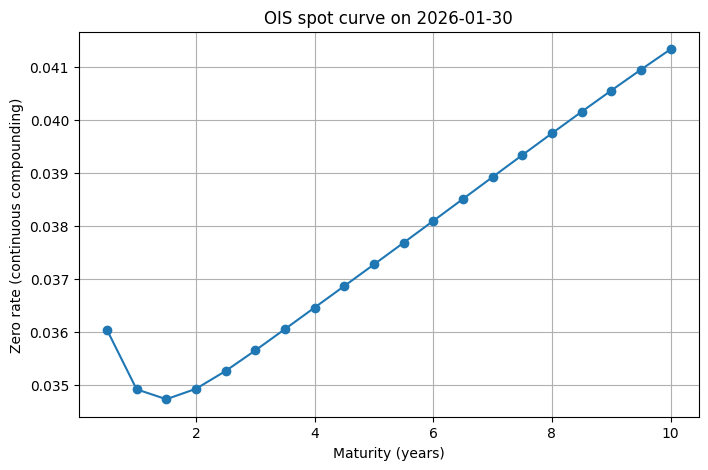

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(market_curve["t"], market_curve["zero_rate_cc"], marker="o")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Zero rate (continuous compounding)")
ax.set_title(f"OIS spot curve on {VALUATION_DATE}")
ax.grid(True)
plt.show()

(a) Constructing interest rate trees. [30 marks] You decide to work with the binomial tree methodology. For this, you have to start with a binomial tree model of risk-neutral short rates. For robustness and simplicity, you decide to experiment both with the Ho-Lee model (HL) and the Black-Derman-Toy (BDT) model, with semi-annual (Δ = 0.5), continuously compounded short-rates.

In [5]:
zero_prices = market_curve["zero_price"].to_numpy().tolist()

# sigma_hl = 0.0311
# sigma_bdt = 0.2142
sigma_hl = 0.01
sigma_bdt = 0.2

hl_tree = calibrate_ho_lee_from_zero_prices(
    zero_prices=zero_prices,
    dt=DT,
    sigma=sigma_hl,
)

bdt_tree = calibrate_simple_bdt_from_zero_prices(
    zero_prices=zero_prices,
    dt=DT,
    sigma=sigma_bdt,
)

# check exact fit
hl_fit = reprice_zero_curve(hl_tree, DT)
bdt_fit = reprice_zero_curve(bdt_tree, DT)

fit_check = pd.DataFrame({
    "t": grid,
    "target_Z": zero_prices,
    "HL_Z": hl_fit,
    "BDT_Z": bdt_fit
})

print(fit_check)

       t  target_Z      HL_Z     BDT_Z
0    0.5  0.982142  0.982142  0.982142
1    1.0  0.965686  0.965686  0.965686
2    1.5  0.949239  0.949239  0.949239
3    2.0  0.932532  0.932532  0.932532
4    2.5  0.915617  0.915617  0.915617
5    3.0  0.898571  0.898571  0.898571
6    3.5  0.881451  0.881451  0.881451
7    4.0  0.864300  0.864300  0.864300
8    4.5  0.847137  0.847137  0.847137
9    5.0  0.829972  0.829972  0.829972
10   5.5  0.812814  0.812814  0.812814
11   6.0  0.795674  0.795674  0.795674
12   6.5  0.778566  0.778566  0.778566
13   7.0  0.761508  0.761508  0.761508
14   7.5  0.744520  0.744520  0.744520
15   8.0  0.727625  0.727625  0.727625
16   8.5  0.710845  0.710845  0.710845
17   9.0  0.694206  0.694206  0.694206
18   9.5  0.677731  0.677731  0.677731
19  10.0  0.661444  0.661444  0.661444


(b) Valuing the mortgage contract [10 marks] As a benchmark, assume that the buyers of the mortgage will prepay optimally and will not default. Following our method of valuing mortgages in Chapter 4 of the lecture notes, find the fixed rates for which the value of the T-year mortgage is (approximately) par under the Ho-Lee model and under the Black-Derman-Toy model. Which one is higher? Do you have any intuition for that?

In [6]:
PRINCIPAL = 100_000.0

hl_res = solve_par_mortgage_rate(
    tree=hl_tree,
    principal=PRINCIPAL,
    dt=DT,
)

bdt_res = solve_par_mortgage_rate(
    tree=bdt_tree,
    principal=PRINCIPAL,
    dt=DT,
)

comparison = pd.DataFrame([
    {
        "model": "HL",
        "K_annual_nominal": hl_res.mortgage_rate,
        "payment": hl_res.coupon_per_period,
        "V0_no_prepay": hl_res.no_prepay_tree[0][0],
        "C0_prepay_option": hl_res.option_tree[0][0],
        "V0_mortgage": hl_res.mortgage_tree[0][0],
    },
    {
        "model": "BDT",
        "K_annual_nominal": bdt_res.mortgage_rate,
        "payment": bdt_res.coupon_per_period,
        "V0_no_prepay": bdt_res.no_prepay_tree[0][0],
        "C0_prepay_option": bdt_res.option_tree[0][0],
        "V0_mortgage": bdt_res.mortgage_tree[0][0],
    },
])
print(comparison.to_string(index=False))

model  K_annual_nominal     payment  V0_no_prepay  C0_prepay_option  V0_mortgage
   HL          0.048665 6374.323575 104740.209804       4740.209804     100000.0
  BDT          0.046885 6320.724408 103859.490783       3859.490783     100000.0


(c) Constructing MBSs [20 marks] As the new product is very successful, UBS decides to issue a pass-through security, an interest rate only security and a principal only security backed by these mortgages. The maturity of these MBSs are the same. However, to recover the cost of securitization, UBS decides to offer them with an interest rate 50 bp lower than the mortgage rate you recommend in problem (b). Following our method in Chapter 4, can you find the fair value for these new products? What is the difference if you use BDT vs Ho-Lee?

In [7]:
pt_coupon_hl = hl_res.mortgage_rate - 0.005
pt_coupon_bdt = bdt_res.mortgage_rate - 0.005

pt_hl = price_pass_through_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.schedule.principal_paid,
    hl_res.trigger_rates,
    pt_coupon_hl,
    DT,
)

po_hl = price_po_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.schedule.principal_paid,
    hl_res.trigger_rates,
    DT,
)

io_hl = price_io_on_tree(
    hl_tree,
    hl_res.schedule.outstanding_principal,
    hl_res.trigger_rates,
    pt_coupon_hl,
    DT,
)

pt_bdt = price_pass_through_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.schedule.principal_paid,
    bdt_res.trigger_rates,
    pt_coupon_bdt,
    DT,
)

po_bdt = price_po_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.schedule.principal_paid,
    bdt_res.trigger_rates,
    DT,
)

io_bdt = price_io_on_tree(
    bdt_tree,
    bdt_res.schedule.outstanding_principal,
    bdt_res.trigger_rates,
    pt_coupon_bdt,
    DT,
)

print("HL PT/PO/IO:", pt_hl[0][0], po_hl[0][0], io_hl[0][0])
print("BDT PT/PO/IO:", pt_bdt[0][0], po_bdt[0][0], io_bdt[0][0])

HL PT/PO/IO: 99060.7892386551 90858.73832413675 8202.050914518337
BDT PT/PO/IO: 99314.67448139518 93573.66976430498 5741.0047170902


(d) Interest rate trees with MC [20 marks] Now you switch to the Monte Carlo methodology. Using N simulations plot a histogram of the simulated interest rates in year T under each of the short rate models. Can you comment on the difference?

 model  n_sims     mean      std       min       p01      p05   median      p95      p99      max  prob_negative
Ho-Lee  100000 0.053019 0.030749 -0.067048 -0.010479 0.003663 0.046089 0.102658 0.116800 0.173369        0.03164
   BDT  100000 0.052820 0.035229  0.003964  0.012287 0.016303 0.038088 0.118068 0.156664 0.485644        0.00000


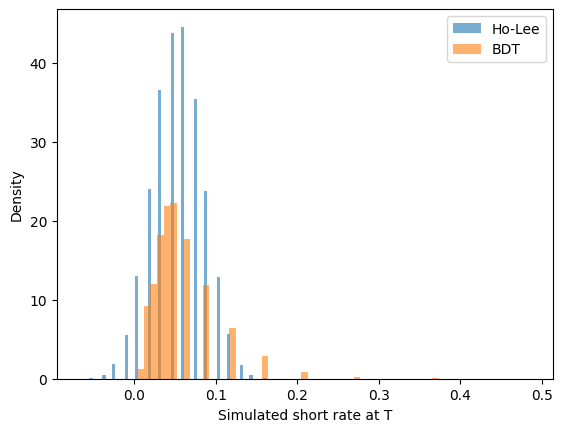

In [8]:
import random
import matplotlib.pyplot as plt

N_SIMS = 100_000
SEED = 12345

def simulate_terminal_rates(tree, n_sims=100_000, seed=12345):
    rng = random.Random(seed)
    n = len(tree)
    out = np.empty(n_sims)

    for s in range(n_sims):
        j = 0
        for _ in range(1, n):
            if rng.random() >= 0.5:
                j += 1
        out[s] = tree[n - 1][j]
    return out

rT_hl = simulate_terminal_rates(hl_tree, n_sims=N_SIMS, seed=SEED)
rT_bdt = simulate_terminal_rates(bdt_tree, n_sims=N_SIMS, seed=SEED)

def summarize_terminal_rates(rates, model_name):
    return {
        "model": model_name,
        "n_sims": len(rates),
        "mean": np.mean(rates),
        "std": np.std(rates, ddof=1),
        "min": np.min(rates),
        "p01": np.quantile(rates, 0.01),
        "p05": np.quantile(rates, 0.05),
        "median": np.quantile(rates, 0.50),
        "p95": np.quantile(rates, 0.95),
        "p99": np.quantile(rates, 0.99),
        "max": np.max(rates),
        "prob_negative": np.mean(rates < 0.0),
    }

summary = pd.DataFrame([
    summarize_terminal_rates(rT_hl, "Ho-Lee"),
    summarize_terminal_rates(rT_bdt, "BDT"),
])
print(summary.to_string(index=False))

plt.hist(rT_hl, bins=60, alpha=0.6, density=True, label="Ho-Lee")
plt.hist(rT_bdt, bins=60, alpha=0.6, density=True, label="BDT")
plt.xlabel("Simulated short rate at T")
plt.ylabel("Density")
plt.legend()
plt.show()

(e) Valuing the mortgage with MC [20 marks] Let us proceed with BDT from here. Use the corresponding mortgage rate you have found in problem (b). As a check on your calculations, you decide to revalue the mortgage contract using a Monte Carlo methodology. What is your point estimate and your confidence interval using N simulations? Is that consistent with your answer in (b)?

In [9]:
mc_bdt = price_mortgage_mc_trigger_rule(
    tree=bdt_tree,
    schedule=bdt_res.schedule,
    trigger_rates=bdt_res.trigger_rates,
    dt=DT,
    n_sims=N_SIMS,
    seed=SEED,
)

print(mc_bdt)

MonteCarloSummary(mean_value=99999.84973622597, standard_error=7.259257216180646, ci_low=99985.3312217936, ci_high=100014.36825065833)


(f) Prepayment modelling [50 marks] You decide to incorporate additional assumptions on prepayment behaviour. (You continue with the BDT model and Monte Carlo.) Real-world mortgage prepayment is driven by multiple factors beyond pure interest rate optimality. Your task is to design, justify, calibrate, and implement a prepayment model that captures realistic borrower behaviour.